# Etapa 1 – MLP Manual
Classificação de cães e gatos usando Perceptron Multicamadas implementado do zero com NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from PIL import Image

## Hiperparâmetros

In [2]:
IMG_SIZE    = 64        # 64x64 pixels em tons de cinza
INPUT_SIZE  = IMG_SIZE * IMG_SIZE  # 4096 features
HIDDEN_SIZE = 128       # neurônios na camada oculta
OUTPUT_SIZE = 1         # saída binária: 0=gato, 1=cachorro
LEARNING_RATE = 0.001
EPOCHS = 50

# Caminho raiz do dataset
DATASET_DIR = 'datasets'  # ajuste se necessário

## Carregamento e Pré-processamento das Imagens

As imagens são:
- Redimensionadas para 64×64
- Convertidas para tons de cinza
- Transformadas em vetores 1D
- Normalizadas para [0, 1]

In [3]:
def load_dataset(split):
    """
    Carrega imagens de datasets/<split>/cat e datasets/<split>/dog.
    Retorna X (N, INPUT_SIZE) e y (N, 1).
    split: 'train', 'validation' ou 'test'
    """
    X, y = [], []
    classes = {'cat': 0, 'dog': 1}

    for class_name, label in classes.items():
        folder = os.path.join(DATASET_DIR, split, class_name)
        if not os.path.exists(folder):
            raise FileNotFoundError(f'Pasta não encontrada: {folder}')

        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            path = os.path.join(folder, fname)
            try:
                img = Image.open(path).convert('L')          # tons de cinza
                img = img.resize((IMG_SIZE, IMG_SIZE))        # 64x64
                arr = np.array(img, dtype=np.float32) / 255.0  # normaliza
                X.append(arr.flatten())                       # vetor 1D
                y.append([label])
            except Exception as e:
                print(f'Erro ao carregar {path}: {e}')

    return np.array(X), np.array(y, dtype=np.float32)


print('Carregando dados...')
X_train, y_train = load_dataset('train')
X_val,   y_val   = load_dataset('validation')
X_test,  y_test  = load_dataset('test')

print(f'Train:      {X_train.shape[0]} amostras')
print(f'Validation: {X_val.shape[0]} amostras')
print(f'Test:       {X_test.shape[0]} amostras')

Carregando dados...
Train:      300 amostras
Validation: 100 amostras
Test:       100 amostras


## Funções de Ativação

In [4]:
def relu(z):
    """Função de ativação ReLU: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivada da ReLU: 1 se z > 0, senão 0"""
    return (z > 0).astype(np.float32)

def sigmoid(z):
    """Função sigmoidal: 1 / (1 + exp(-z))"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

## Função de Perda – Binary Cross-Entropy

In [5]:
def binary_cross_entropy(y_true, y_pred):
    """
    BCE = -mean(y * log(ŷ) + (1-y) * log(1-ŷ))
    Clamp para evitar log(0).
    """
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## Inicialização dos Pesos

Usando inicialização He (recomendada para ReLU).

In [6]:
np.random.seed(42)

# Camada oculta: (INPUT_SIZE → HIDDEN_SIZE)
W1 = np.random.randn(INPUT_SIZE, HIDDEN_SIZE).astype(np.float32) * np.sqrt(2.0 / INPUT_SIZE)
b1 = np.zeros((1, HIDDEN_SIZE), dtype=np.float32)

# Camada de saída: (HIDDEN_SIZE → OUTPUT_SIZE)
W2 = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE).astype(np.float32) * np.sqrt(2.0 / HIDDEN_SIZE)
b2 = np.zeros((1, OUTPUT_SIZE), dtype=np.float32)

print(f'W1: {W1.shape}  b1: {b1.shape}')
print(f'W2: {W2.shape}  b2: {b2.shape}')

W1: (4096, 128)  b1: (1, 128)
W2: (128, 1)  b2: (1, 1)


## Treinamento – Forward, Backpropagation e Atualização de Pesos

In [7]:
train_losses = []
val_losses   = []

start = time.time()

for epoch in range(EPOCHS):
    # ========================
    # FORWARD PROPAGATION
    # ========================
    z1 = np.dot(X_train, W1) + b1   # (N, HIDDEN_SIZE)
    a1 = relu(z1)                   # (N, HIDDEN_SIZE)
    z2 = np.dot(a1, W2) + b2        # (N, OUTPUT_SIZE)
    y_pred = sigmoid(z2)            # (N, OUTPUT_SIZE)

    # ========================
    # FUNÇÃO DE PERDA
    # ========================
    loss = binary_cross_entropy(y_train, y_pred)

    # ========================
    # BACKPROPAGATION
    # ========================
    # Gradiente da BCE + sigmoide combinados: dL/dz2 = y_pred - y_true
    dz2 = y_pred - y_train                             # (N, 1)
    dW2 = np.dot(a1.T, dz2) / len(X_train)            # (HIDDEN_SIZE, 1)
    db2 = np.mean(dz2, axis=0, keepdims=True)          # (1, 1)

    # Gradiente na camada oculta
    da1 = np.dot(dz2, W2.T)                            # (N, HIDDEN_SIZE)
    dz1 = da1 * relu_derivative(z1)                    # (N, HIDDEN_SIZE)
    dW1 = np.dot(X_train.T, dz1) / len(X_train)       # (INPUT_SIZE, HIDDEN_SIZE)
    db1 = np.mean(dz1, axis=0, keepdims=True)          # (1, HIDDEN_SIZE)

    # ========================
    # ATUALIZAÇÃO DOS PESOS (Gradiente Descendente)
    # ========================
    W2 -= LEARNING_RATE * dW2
    b2 -= LEARNING_RATE * db2
    W1 -= LEARNING_RATE * dW1
    b1 -= LEARNING_RATE * db1

    # ========================
    # VALIDAÇÃO
    # ========================
    val_z1   = np.dot(X_val, W1) + b1
    val_a1   = relu(val_z1)
    val_z2   = np.dot(val_a1, W2) + b2
    val_pred = sigmoid(val_z2)
    val_loss = binary_cross_entropy(y_val, val_pred)

    train_losses.append(loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Época {epoch+1:3d}/{EPOCHS} | Loss: {loss:.4f} | Val Loss: {val_loss:.4f}')

end = time.time()
training_time = end - start
print(f'\nTempo de treinamento: {training_time:.2f} segundos')

Época   1/50 | Loss: 0.6952 | Val Loss: 0.7010
Época  10/50 | Loss: 0.6926 | Val Loss: 0.6998
Época  20/50 | Loss: 0.6905 | Val Loss: 0.6997
Época  30/50 | Loss: 0.6888 | Val Loss: 0.6996
Época  40/50 | Loss: 0.6873 | Val Loss: 0.6995
Época  50/50 | Loss: 0.6858 | Val Loss: 0.6994

Tempo de treinamento: 1.03 segundos


## Avaliação no Conjunto de Teste

In [8]:
# Forward no teste
z1_test   = np.dot(X_test, W1) + b1
a1_test   = relu(z1_test)
z2_test   = np.dot(a1_test, W2) + b2
pred_test = sigmoid(z2_test)

pred_labels = (pred_test > 0.5).astype(int)
accuracy    = np.mean(pred_labels == y_test)

print(f'Acurácia no teste: {accuracy * 100:.2f}%')
print(f'Tempo de treinamento: {training_time:.2f} segundos')

Acurácia no teste: 53.00%
Tempo de treinamento: 1.03 segundos


## Matriz de Confusão (Manual)

In [9]:
TP = int(np.sum((pred_labels == 1) & (y_test == 1)))
TN = int(np.sum((pred_labels == 0) & (y_test == 0)))
FP = int(np.sum((pred_labels == 1) & (y_test == 0)))
FN = int(np.sum((pred_labels == 0) & (y_test == 1)))

print('Matriz de Confusão:')
print(f'              Predito Gato  Predito Cachorro')
print(f'Real Gato         {TN:5d}          {FP:5d}')
print(f'Real Cachorro     {FN:5d}          {TP:5d}')

# Métricas adicionais
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'\nPrecisão:  {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Matriz de Confusão:
              Predito Gato  Predito Cachorro
Real Gato            28             22
Real Cachorro        25             25

Precisão:  0.5319
Recall:    0.5000
F1-Score:  0.5155


## Gráfico de Loss (Treino vs Validação)

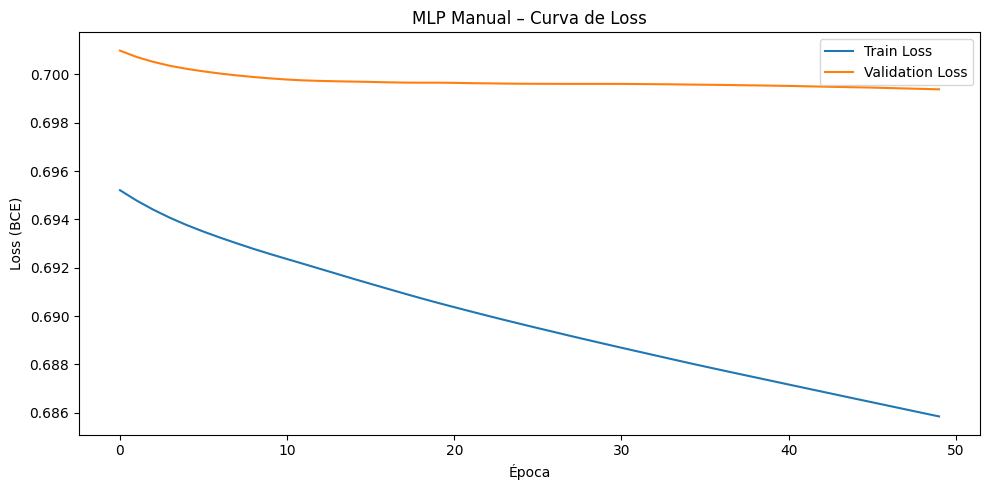

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Época')
plt.ylabel('Loss (BCE)')
plt.title('MLP Manual – Curva de Loss')
plt.legend()
plt.tight_layout()
plt.show()

GERACAO DE RELATORIO

In [11]:
import datetime

relatorio = f"""================================================================
RELATÓRIO – ETAPA 1: MLP MANUAL
Gerado em: {datetime.datetime.now().strftime('%d/%m/%Y %H:%M:%S')}
================================================================

CONFIGURAÇÕES
-------------
Tamanho da imagem   : {IMG_SIZE}x{IMG_SIZE} (tons de cinza)
Tamanho da entrada  : {INPUT_SIZE} features
Neurônios ocultos   : {HIDDEN_SIZE}
Épocas              : {EPOCHS}
Learning rate       : {LEARNING_RATE}
Função de ativação  : ReLU (oculta) + Sigmoid (saída)
Função de perda     : Binary Cross-Entropy
Otimizador          : Gradiente Descendente (manual)

DATASET
-------
Amostras de treino      : {X_train.shape[0]}
Amostras de validação   : {X_val.shape[0]}
Amostras de teste       : {X_test.shape[0]}
Total                   : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}

RESULTADOS DO TREINAMENTO
--------------------------
Loss final (treino)     : {train_losses[-1]:.4f}
Loss final (validação)  : {val_losses[-1]:.4f}
Loss mínima (treino)    : {min(train_losses):.4f} (época {train_losses.index(min(train_losses))+1})
Loss mínima (validação) : {min(val_losses):.4f} (época {val_losses.index(min(val_losses))+1})
Tempo de treinamento    : {training_time:.2f} segundos

RESULTADOS NO TESTE
--------------------
Acurácia   : {accuracy * 100:.2f}%
Precisão   : {precision:.4f}
Recall     : {recall:.4f}
F1-Score   : {f1:.4f}

MATRIZ DE CONFUSÃO
-------------------
                  Predito Gato   Predito Cachorro
Real Gato             {TN:5d}            {FP:5d}
Real Cachorro         {FN:5d}            {TP:5d}

  TP (acertou cachorro) : {TP}
  TN (acertou gato)     : {TN}
  FP (gato → cachorro)  : {FP}
  FN (cachorro → gato)  : {FN}
================================================================
"""

print(relatorio)

with open('relatorio_mlp.txt', 'w', encoding='utf-8') as f:
    f.write(relatorio)

print('Relatório salvo em: relatorio_mlp.txt')

RELATÓRIO – ETAPA 1: MLP MANUAL
Gerado em: 22/06/2026 18:51:20

CONFIGURAÇÕES
-------------
Tamanho da imagem   : 64x64 (tons de cinza)
Tamanho da entrada  : 4096 features
Neurônios ocultos   : 128
Épocas              : 50
Learning rate       : 0.001
Função de ativação  : ReLU (oculta) + Sigmoid (saída)
Função de perda     : Binary Cross-Entropy
Otimizador          : Gradiente Descendente (manual)

DATASET
-------
Amostras de treino      : 300
Amostras de validação   : 100
Amostras de teste       : 100
Total                   : 500

RESULTADOS DO TREINAMENTO
--------------------------
Loss final (treino)     : 0.6858
Loss final (validação)  : 0.6994
Loss mínima (treino)    : 0.6858 (época 50)
Loss mínima (validação) : 0.6994 (época 50)
Tempo de treinamento    : 1.03 segundos

RESULTADOS NO TESTE
--------------------
Acurácia   : 53.00%
Precisão   : 0.5319
Recall     : 0.5000
F1-Score   : 0.5155

MATRIZ DE CONFUSÃO
-------------------
                  Predito Gato   Predito Cachorro
Re